## Proyecto. Simulaciones del sistema de Lorenz.

---

### Definición del sistema de Lorenz.

El sistema de Lorenz es un conjunto de tres ecuaciones diferenciales ordinarias no lineales que modelan el flujo de convección atmosférica en un fluido calentado desde abajo y enfriado desde arriba. Este sistema fue propuesto por el meteorólogo Edward N. Lorenz en el año 1963. La idea de este sistema era simplificar las ecuaciones de Navier-Stokes.

Las ecuaciones del sistema están dadas por:

$$\begin{equation}\begin{cases}\dot{x}=\sigma(y-x)\\\dot{y}=x(\rho-z)-y\\\dot{z}=x\cdot y-\beta\cdot z\end{cases}\end{equation}$$

Donde 

- $x(t)$ es la tasa de convección del fluido.

- $y(t)$ es la diferencia de temperatura horizontal.

- $z(t)$ es la diferencia de temperatura vertical.

- $\sigma$ representa el número de Prandtl, el cual está relacionado con la viscocidad.

- $\rho$ representa el número de Rayleigh, el cual está relacionado con el gradiente térmico.

- $\beta$ es una parámetro geométrico, representa la proporción del tamaño del dominio.

Cada una de las variables dependientes están dadas en función del tiempo, siendo un sistema dinámico tridimensional no lineal que representa un campo vectorial $\vec{F}(x,y,z)$.

Los parámetros $\sigma, \rho, \beta$, dependiendo de sus valores, pueden generar soluciones periódicas, inestables o caóticas. Por ejemplo, para valores clásicos de dichos parámetros ($\sigma=10,\rho=28,\beta=8/3$) el sistema entra en una fase caótica conocida como el atractor de Lorenz.

En cuanto a sus aplicaciones, el sistema de Lorenz fue diseñado para un modelo meteorológico, aun así, representa un paradigma en el estudio de otras áreas importantes como: Dinámica de fluidos, sistemas caóticos, climatología, sistemas no lineales.

---

Ahora, habiendo definido conceptualmente lo que es el **sistema de Lorenz**, se define la función vectorial $\vec{F}(x,y,z)$ que le representa en Python, mediante el siguiente código:

In [1]:
import numpy as np

def lorenz_system(state, sigma, rho, beta) :
    
    x, y, z = state
    
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    return np.array([dx, dy, dz])

Con ello, se crea el vector que define el sistema de Lorenz.

A continuación, se plantean los métodos numéricos que se van a utilizar para darle solución a las ecuaciones diferenciales y poder simular el sistema de Lorenz y consecuentemente, obtener valores para la función vectorial que le representa para diferentes parámetros y condiciones iniciales.

Para resolver las ecuaciones diferenciales ordinarias se utilizarán los métodos de **Euler** y **Runge-Kutta orden 4**. Ambos métodos numéricos sirven para **aproximar** la solución de sistemas de ecuaciones diferenciales ordinarias, tal y como lo es el sistema de Lorenz, esto dado que para un sistema como este no existe una solución analítica cerrada debido a la complejidad del problema no lineal.

Como se definió anteriormente, el sistema de Lorenz es el de EDOs de primer orden siguiente

$$\frac{d\vec{x}}{dt}=\vec{F}(\vec{x},t)$$

Donde

- $\vec{x}(t)=[x(t),y(t),z(t)]$

- $\vec{F}$ es el campo vectorial definido por las ecuaciones del sistema.

Se pretende aproximar los valores de $x(t),y(t),z(t)$ para una secuencia de tiempos $t_0,t_1,\dots,t_n$

El primer método es:

- **Método de Euler.**

El método de Euler utiliza la derivada como aproximacción de la diferencia entre dos puntos cercanos, para sistemas de ecuaciones diferenciales. Se define como sigue:

$$\vec{x}_{n+1}=\vec{x}_n+h\cdot\vec{F}(\vec{x}_n)$$

Donde 

- $h$ es el tamaño del paso.

Se define el método de Euler en Python de la siguiente manera:

In [2]:
def euler_method(f, initial_state, t, sigma, rho, beta) :
    
    h = t[1] - t[0]
    
    n = len(t)
    
    result = np.zeros((n,3))
    result[0] = initial_state
    
    for i in range(1, n) :
        result[i] = result[i - 1] + h * f(result[i - 1], sigma, rho, beta)
        
    return result

El segundo método numérico es:

- **Método de Runge-Kutta de 4° orden.**

El método de Runge-Kutta para cuarto orden es un método mucho más preciso, evalúa varias veces la deriavada por cada paso, se define como sigue:

$$x_{n+1}=x_n+\frac{h}{6}\cdot(k_1+2\cdot k_2+2\cdot k_3+k_4)$$

Donde:

- $k_1=f(x_n)$

- $k_2=f(x_n+\frac{h}{2}\cdot k_1)$

- $k_3=f(x_n+\frac{h}{2}\cdot k_2)$

- $k_4=f(x_n+h\cdot k_3)$

Se define el método de Runge-Kutta de 4° orden en Python, así:

In [3]:
def rk4_method(f, initial_state, t, sigma, rho, beta) :
    
    h = t[1] - t[0]
    
    n = len(t)
    
    result = np.zeros((n,3))
    result[0] = initial_state
    
    for i in range(1, n) :
        
        k1 = f(result[i - 1], sigma, rho, beta)
        k2 = f(result[i - 1] + 0.5 * h * k1, sigma, rho, beta)
        k3 = f(result[i - 1] + 0.5 * h * k2, sigma, rho, beta)
        k4 = f(result[i - 1] + h * k3, sigma, rho, beta)
        
        result[i] = result[i - 1] + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        
    return result


---

Habiendo definido los métodos para la resolución del sistema, se procede a realizar el planteamiento para la simulación de dicho sistema para condiciones iniciales dadas y parámetros diferentes para tres casos distintos.

Para ello, se realizarán tres simulaciones con condiciones iniciales y parámetros dados. Para las simulaciones se realizará lo siguiente

- Se define la función que describe $\vec{F}(x,y,z)$.

- Se establece una condición inicial $(x_0,y_0,z_0)$.

- Se construye el vector de tiempos que recibe la función $t=[t_0,t_1,\dots,t_n]$.

- Se aplican ambos métodos, Euler y Runge-Kutta para aproximar los valores de $x(t),y(t),z(t)$.

- Finalmente, se grafican las soluciones para analizar el comportamiento del sistema a lo largo del tiempo.

Primeramente, se define el tiempo de simulación y el paso:

In [4]:
t0, tf = 0, 40
h = 0.01 # paso
t = np.arange(t0, tf, h) # vector de tiempos

Ahora, se definen los parámetros de simulación para cada uno de los casos solicitados:

In [5]:
# parametros

params_case1 = {'sigma' : 10, 'rho' : 28, 'beta' : 8 / 3}
params_case2 = params_case1 # los parametros para los casos 1 y 2 son los mismos
params_case3 = {'sigma' : 9, 'rho' : 18, 'beta' : 10 / 3}

# condiciones iniciales

initial_case1 = [1,1,1]
initial_case2 = [1.002025, 0.2, 0.4]
initial_case3 = [2, 0.009, 0.7]

Habiendo definido los parámetros y condiciones iniciales para cada uno de los casos, se realiza la simulación utilizando **método de Euler** y **método de Runge-Kutta** en cada caso y se almacenan los resultados.

In [6]:
results = {}

# Caso 1

results['Euler_1'] = euler_method(lorenz_system, initial_case1, t, **params_case1)
results['Rk4_1'] = rk4_method(lorenz_system, initial_case1, t, **params_case1)

# Caso 2

results['Euler_2'] = euler_method(lorenz_system, initial_case2, t, **params_case2)
results['Rk4_2'] = rk4_method(lorenz_system, initial_case2, t, **params_case2)

# Caso 3

results['Euler_3'] = euler_method(lorenz_system, initial_case3, t, **params_case3)
results['Rk4_3'] = rk4_method(lorenz_system, initial_case3, t, **params_case3)

A continuación, se codifica una función que permitirá visualizar las gráficas $x(t),y(t),z(t)$ para cada uno de los casos.

In [7]:
import matplotlib.pyplot as plt

def plot_xyz(t, data, title) :
    
    fig, axs = plt.subplots(3, 1, figsize=(10,7), sharex=True)
    labels = ['x(t)', 'y(t)', 'z(t)']
    
    for i in range(3) :
        
        axs[i].plot(t, data[:, 1], label=labels[i])
        axs[i].legend(loc='upper right')
        axs[i].grid()
        
    plt.suptitle(title)
    plt.xlabel('Tiempo t')
    plt.tight_layout()
    plt.show()

Teniendo la función graficadora, se procede a generar las gráficas solicitadas con los resultados obtenidos.

Graficas para caso 1


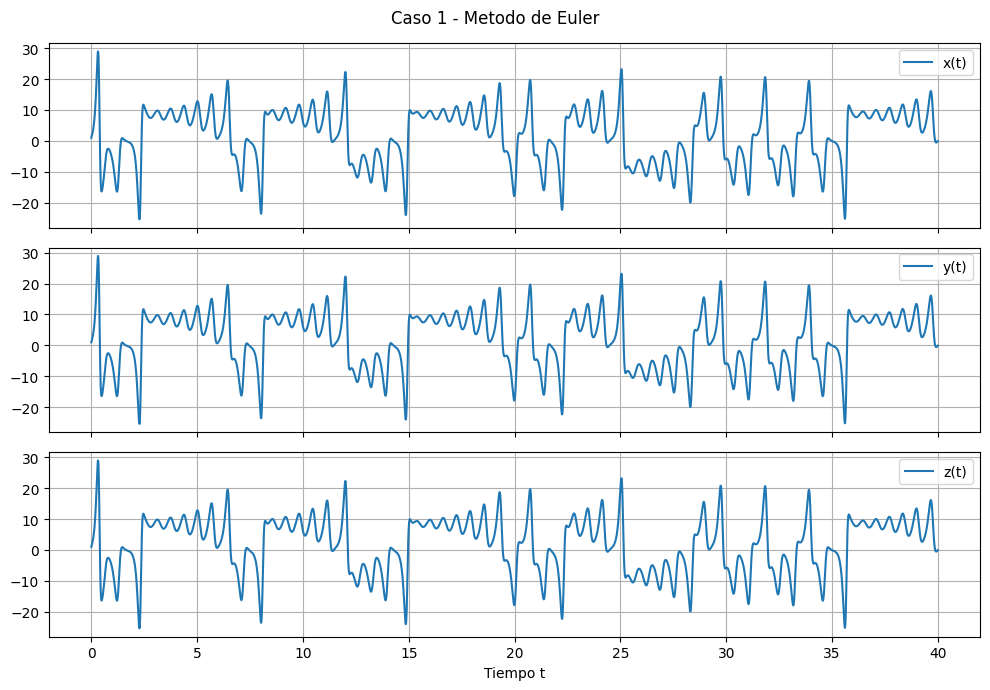

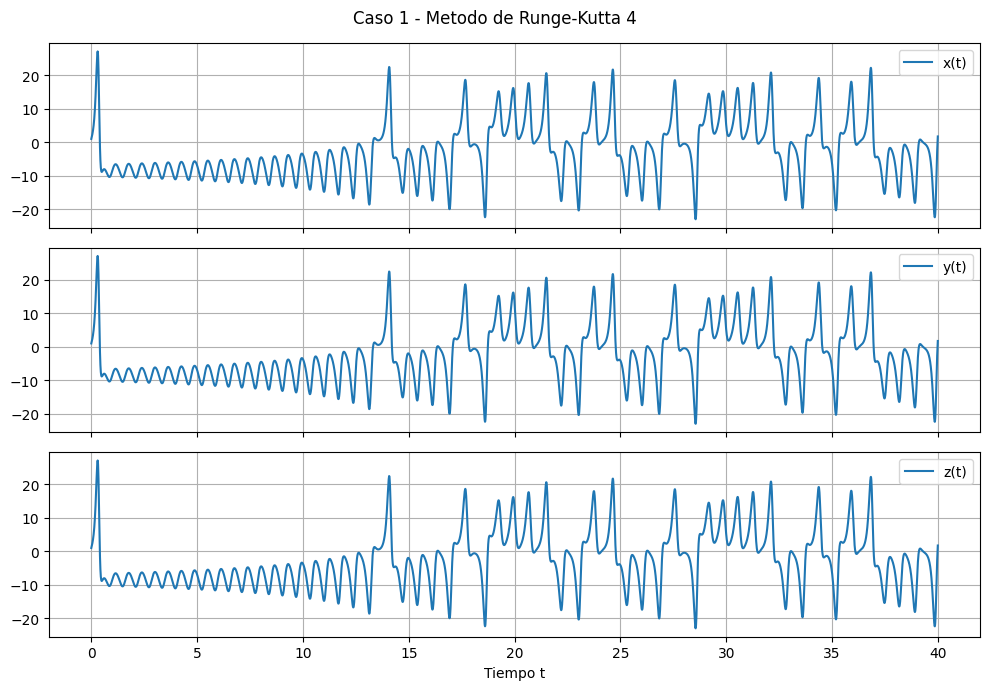

Graficas para caso 2


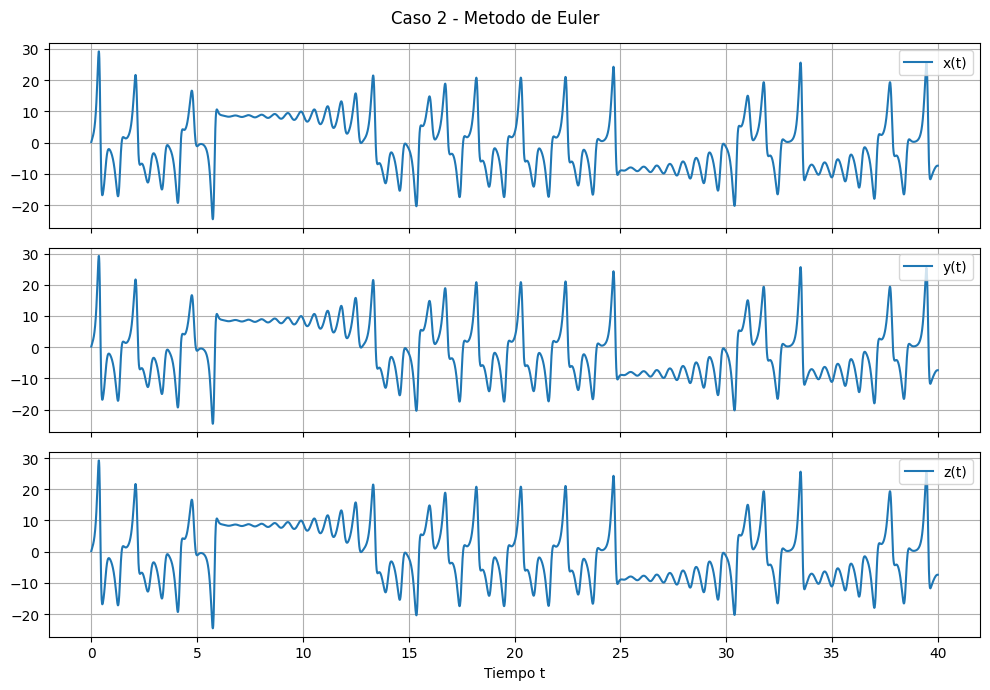

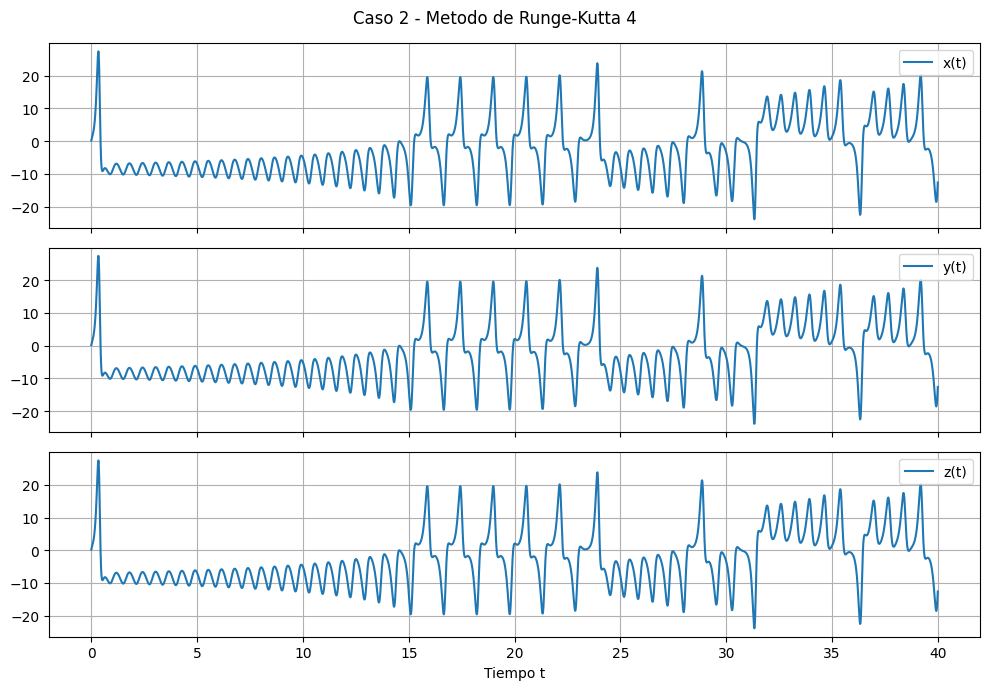

Graficas para caso 3


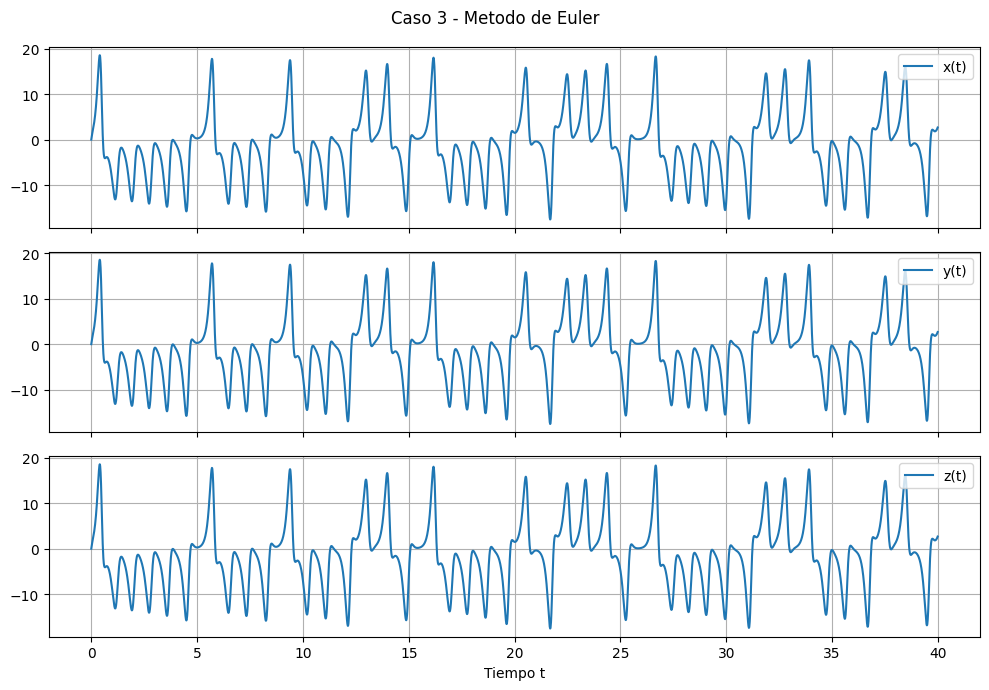

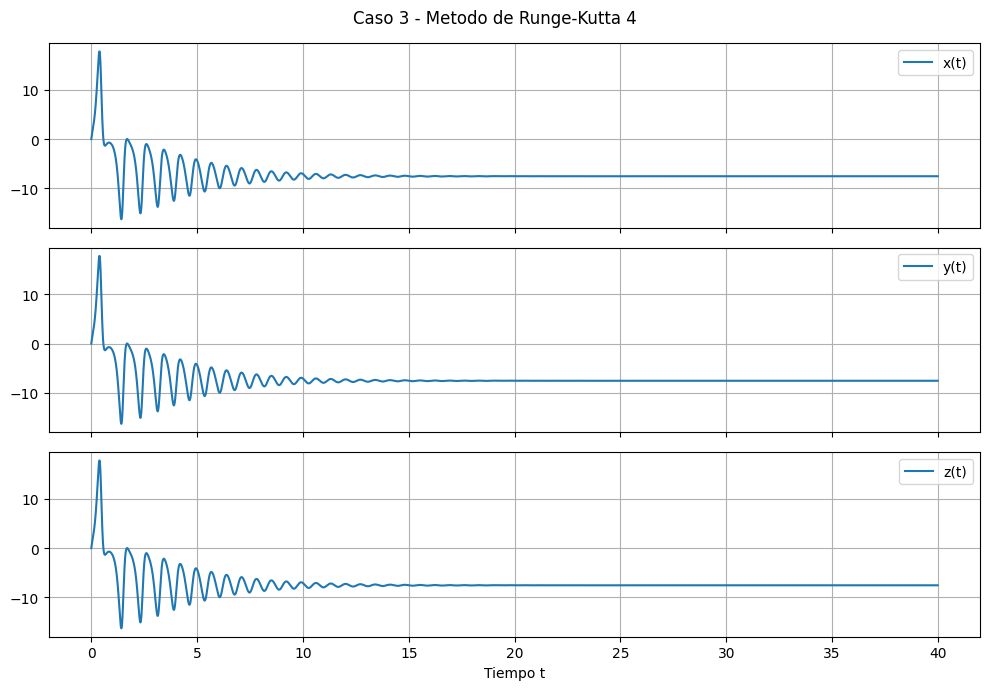

In [8]:
print("\033[94mGraficas para caso 1\033[0m")

plot_xyz(t, results['Euler_1'], 'Caso 1 - Metodo de Euler')
plot_xyz(t, results['Rk4_1'], 'Caso 1 - Metodo de Runge-Kutta 4')

print("\033[94mGraficas para caso 2\033[0m")

plot_xyz(t, results['Euler_2'], 'Caso 2 - Metodo de Euler')
plot_xyz(t, results['Rk4_2'], 'Caso 2 - Metodo de Runge-Kutta 4')

print("\033[94mGraficas para caso 3\033[0m")

plot_xyz(t, results['Euler_3'], 'Caso 3 - Metodo de Euler')
plot_xyz(t, results['Rk4_3'], 'Caso 3 - Metodo de Runge-Kutta 4')

Al haber obtenido las gráficas de como cambia el sistema para cada variable dependiente en función de la variable independiente de tiempo, se requiere realizar un análisis de cómo varía la dinámica del sistema ante los cambios en las condiciones iniciales, y explicar cómo afecta la variación de los parámetros en el comportamiento del sistema.

Para ello, se realiza una simulación en Python que permitirá comparar los primeros dos casos con el método de Runge-Kutta y encontrar la sensibilidad del sistema a cambios en las condiciones iniciales, y una segunda simulación que permitirá analizar cómo afecta la variación de los parámetros del sistema, siempre con el método de Runge-Kutta, ahora, utilizando los casos 1 y 3.

In [9]:
def compare_initial_conditions(t, data1, data2, label1, label2) :
    
    fig, axs = plt.subplots(3, 1, figsize=(10,7), sharex=True)
    labels = ['x(t)', 'y(t)', 'z(t)']
    
    for i in range(3) :
        
        axs[i].plot(t, data1[:, 1], label=label1)
        axs[i].plot(t, data2[:, 1], label=label2, linestyle='dashed')
        axs[i].legend(loc='upper right')
        axs[i].grid()
        
    plt.suptitle("Comparacion de evolucion temporal para diferentes condiciones iniciales")
    plt.xlabel("Tiempo t")
    plt.tight_layout()
    plt.show()


---

#### Variación de condiciones iniciales.

Para los casos 

- [1, 1, 1]

- [1,002025, 0.2, 0.4]

Con mismos parámetros

- $\rho=28,\sigma=10,\beta=8/3$

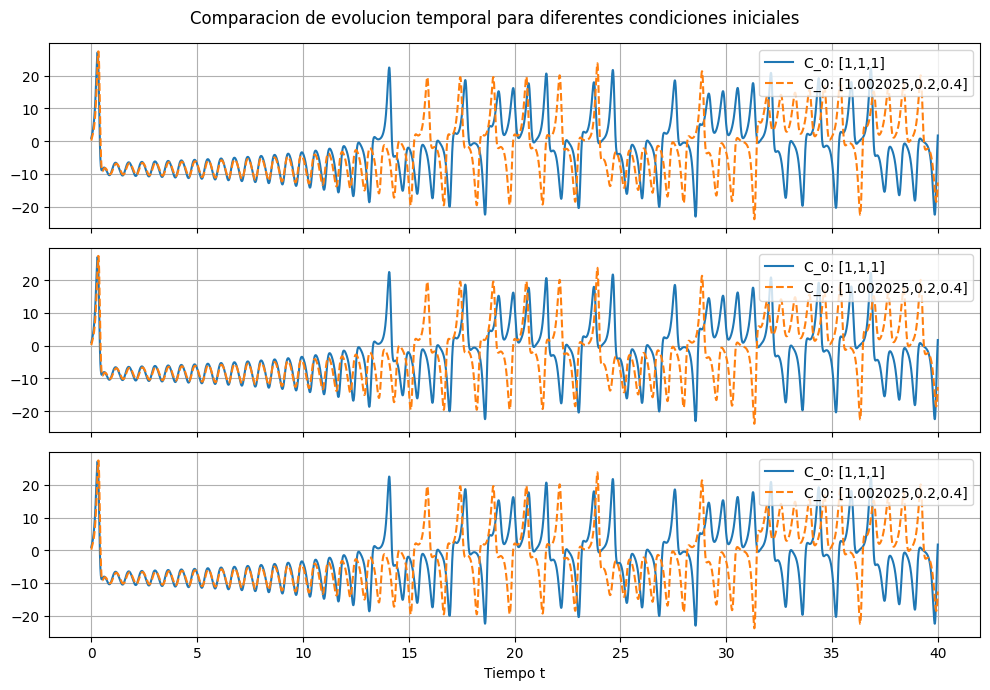

In [10]:
compare_initial_conditions(t, results['Rk4_1'], results['Rk4_2'], "C_0: [1,1,1]", "C_0: [1.002025,0.2,0.4]")

**Análisis ante cambios en las condiciones iniciales:** Se puede observar que, al principio las trayectorias son bastante similares, después de cierto tiempo, dependiendo del paso, divergen rápidamente, mostrando un comportamiento caótico.

En la fase inicial, para $t<5$, las soluciones para $x(t), y(t), z(t)$ son similares en ambos casos, el sistema parece predecible y estable. Cuando el sistema llega a un punto crítico, aproximadamente en $t\in[10,15]$, las trayectorias comienzan a divergir abruptamente, las gráficas ya no se superponen y siguen rumbos completamente diferentes.

En el espacio fase, ambas trayectorias caen en el atractor de Lorenz, pero giran en lóbulos diferentes, por lo que muestran trayectorias impredecibles.

El sistema de Lorenz muestra un comportamiento altamente sensible a las condiciones iniciales, siendo esta una característica clave de los sistemas caóticos. Las trayectorias parten de puntos prácticamente idénticos y se separan exponencialmente en el tiempo, lo cual implica una imposibilidad de predecir el futuro a largo plazo, incluso si los datos iniciales contienen errores mínimos.

El fenómeno ilustrado permite interpretar que se está generando un **efecto mariposa**. Este fenómeno fue descrito por Lorenz con la siguiente frase:

> "El aleteo de una mariposa en Brasil puede desencadenar un tornado en Texas." [1]

En el sistema de Lorenz, pequeñas variaciones en las condiciones iniciales producen evoluciones temporalmente distintas, que divergen rápidamente después de un intervalo corto. Esta sensibilidad es una firma del caos determinista, donde, aunque las reglas del sistema son fijas y conocidas, su evolución a largo plazo es impredecible debido a la dependencia exponencial del estado inicial.


---

#### Variación de parámetros del sistema.

Para los casos

- $\rho=28,\sigma=10,\beta=8/3$

- $\rho=18,\sigma=9,\beta=10/3$

Con mismas condiciones iniciales

- [1, 1, 1]

- [2, 0.009, 0.7]

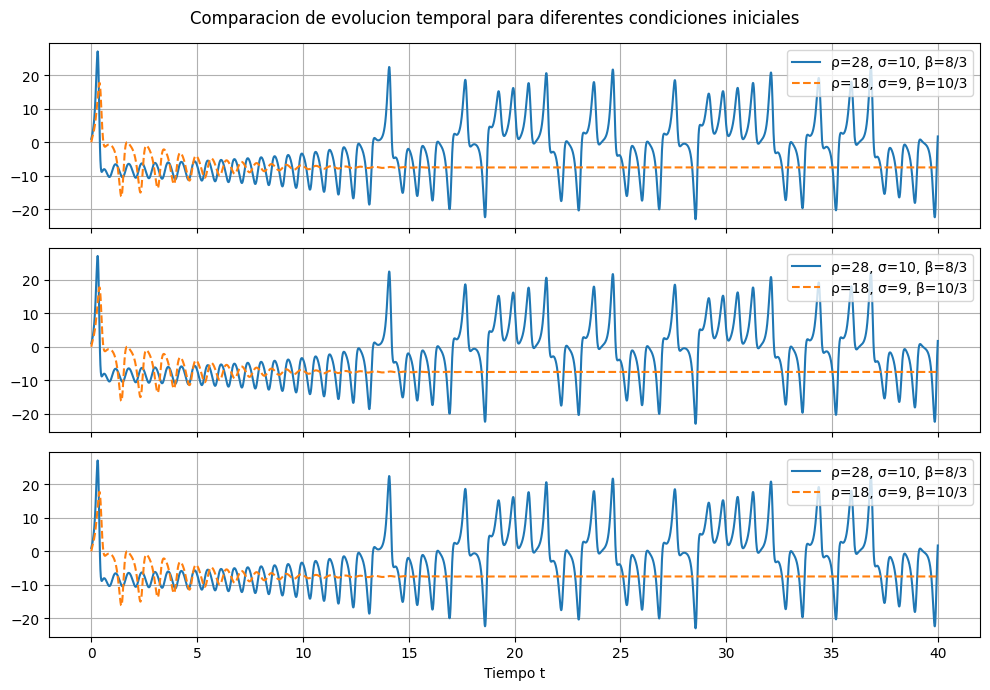

In [11]:
compare_initial_conditions(t, results['Rk4_1'], results['Rk4_3'], "\u03C1=28, \u03C3=10, \u03B2=8/3", "\u03C1=18, \u03C3=9, \u03B2=10/3")

**Análisis ante la variación de parámetros:** Se observa un cambio en la estructura del atractor en el número de espiras, los ciclos, la densidad de las trayectorias, y puede observarse cómo el sistema cambia de un comportamiento oscilatorio a un comportamiento más estable o más errático.

Al comparar los casos 1 y 3, se puede observar un atractor visualmente distinto, el caso 1 posee los parámetros clásicos de Lorenz, formando el típico atractor caótico con dos lóbulos, las trayectorias oscilan entre ellos de manera impredecible. Para el caso 3, el atractor es más compacto y menos regular, la dinámica es más contenida, lo que indica un caos menor.

Se puede observar para el caso 1 que las soluciones generan oscilasiones amplias y abruptas, con giros que indican fuerte no linealidad. En el caso 3, las soluciones poseen menor amplitud y comportamiento periódico.

La estabilidad es relativa, dado que, cuando el sistema se establece con $\rho=28$ cae en el régimen caótico, cuando se reduce a $\rho=18$ y se ajusta $\beta$ el sistema pierde el caos y tiende hacia un comportamiento más estable y cíclico.

En conclusión, la variación de los parámetros del sistema de Lorenz transforma radicalmente su comportamiento. El análisis permite observar cómo los fenómenos caóticos dependen fuertemente de los parámetros, por tanto, en casos reales, de cambios físicos, en modelos meteorológicos, por ejemplo, alteran completamente la dinámica.

---

En este momento, se pretende verificar cual de los dos métodos numéricos es más adecuado para el tipo de simulaciones que se están realizando. Compararlos, es un proceso fundamental para encontrar la mejor solución ante sistemas como el de Lorenz, que es un sistema no lineal, sensible a condiciones iniciales y propenso al caos.

Para compararlo e identificar el método más adecuado, se seguirá una estrategia que consiste en visualizar las trayectorias de las variables dependientes a lo largo del tiempo, se simulará el sistema para ambos métodos y se graficarán las curvas $x(t),y(t),z(t)$, y así poder observar como se desvían con el tiempo.

Para ello, establecemos las condiciones iniciales y parámetros siguientes:

- $\sigma=10,\rho=28,\beta=8/3$

- $(x_0,y_0,z_0)=(1,1,1)$

- $t\in[0,20]$

- $h=0.01$

Se utilizarán los métodos ya implementados en Python de Euler y Runge-Kutta, ambos reciben el sistema planteado y generan soluciones $(x_i,y_i,z_i)$ para cada instante de tiempo.

A continuación, se ejecuta la simulación:

In [12]:
# definiendo parametros y condiciones iniciales

t = np.arange(0,20,0.01) # con paso h
initial_state = [1,1,1]
params = {'sigma': 10, 'rho' : 28, 'beta' : 8 / 3 }

# obteniendo soluciones por ambos metodos

euler_sol = euler_method(lorenz_system, initial_state, t, **params)
rk4_sol = rk4_method(lorenz_system, initial_state, t, **params)

Habiendo ejecutado la simulación, se compara gráficamente la precisión obtenida para ambos métodos, comparando $x(t)$ para ambas soluciones obtenidas:

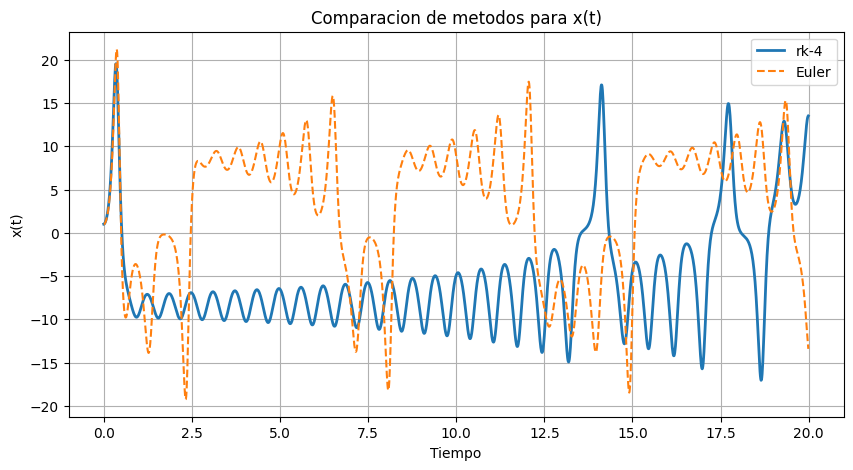

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(t, rk4_sol[:, 0], label='rk-4', lw=2)
plt.plot(t, euler_sol[:, 0], label='Euler', linestyle='dashed')
plt.title("Comparacion de metodos para x(t)")
plt.xlabel("Tiempo")
plt.ylabel("x(t)")
plt.legend()
plt.grid()
plt.show()

Se observa en la comparación de los métodos que, al principio las curvas de Euler y Runge-Kutta son bastante similares, a medida el tiempo transcurre, la curva de Euler se desvía notoriamente, lo cual muestra inestabilidad y pérdida de precisión.

Para verificar dicha proposición, se puede realizar el cálculo del error relativo, tomando como referencia el método de Runge-Kutta, dada la gráfica en donde se puede observar que es más preciso. Calculamos el error relativo, así:

$$\text{Error relativo}=\frac{|\text{Euler}-\text{rk4}|}{|\text{rk4}+\epsilon|}$$

A continuación, se realiza el cálculo del error relativo en Python:

In [14]:
epsilon = 1e-10
error = np.abs(euler_sol - rk4_sol) / (np.abs(rk4_sol) + epsilon)
max_error = np.max(error, axis=0)

print("Maximo error relativo por variable:")

print(f"x(t): {max_error[0]:.4f}")
print(f"y(t): {max_error[1]:.4f}")
print(f"z(t): {max_error[2]:.4f}")

Maximo error relativo por variable:
x(t): 1296.2247
y(t): 1883.7781
z(t): 2.7342


Los resultados obtenidos indican que el error de Euler crece rápidamente en el tiempo, especialmente en los sistemas caóticos. El sistema de Lorenz, dado que no es lineal y es caótico, es altamente sensible a errores numéricos, Euler es estable dadas ciertas condiciones, con pasos grandes tiende a explotar, Runge-Kutta es un método más estable, incluso con pasos moderados.

En conclusión, Runge-Kutta es un método más preciso y estable con pasos razonables, el comportamiento del atractor se mantiene bien definio, por lo tanto, es altamente superior a Euler para simular de mejor manera el sistema de Lorenz, reproduce correctamente la estructura caótica, permitiendo generar visualizaciones y análisis más confiables.

---

Para finalizar, se realiza una animación en tres dimensiones que muestra la evolución temporal del sistema de Lorenz, utilizando el método más adecuado para simulaciones Runge-Kutta de 4° orden. 

La animación muestra cómo la trayectoria evoluciona en el espacio de fase tridimensional $(x,y,z)$ con el tiempo. Para realizar la animación se utiliza la función que define el sistema de Lorenz, implementada en Python, así como el método de Runge-Kutta implementado igualmente en Python.

A continuación, se construye la animación:

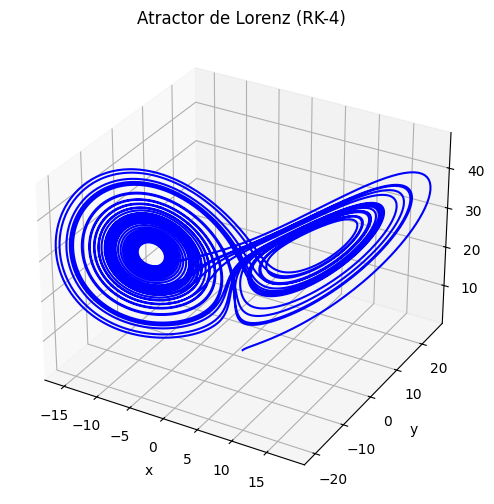

In [15]:
t = np.linspace(0,40,10000)
initial_state = [1,1,1]
sigma, rho, beta = 10,28,8/3

data = rk4_method(lorenz_system, initial_state, t, sigma, rho, beta)

# Animacion 

from matplotlib.animation import FuncAnimation as fa

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim((min(data[:, 0]), max(data[:, 0])))
ax.set_ylim((min(data[:, 1]), max(data[:, 1])))
ax.set_zlim((min(data[:, 2]), max(data[:, 2])))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Atractor de Lorenz (RK-4)")

line, = ax.plot([], [], [], lw=1.5, color='blue')

def update(frame):
    line.set_data(data[:frame, 0], data[:frame, 1])
    line.set_3d_properties(data[:frame, 2])
    return line,

ani = fa(fig, update, frames=range(100, len(data), 10), interval=30, blit=True)

# Guardando animacion como mp4

ani.save("atractor_lorenz_rk4.mp4", writer='ffmpeg', dpi=200)

La siguiente animación muestra la trayectoria tridimensional del sistema de Lorenz simulada con el método de Runge-Kutta de cuarto orden. El atractor caótico emerge con el tiempo a partir de la condición inicial $(x_0, y_0, z_0) = (1, 1, 1)$.

In [16]:

# Generando vista previa embebida

from IPython.display import Video

Video("atractor_lorenz_rk4.mp4", width=600)

Y así, se ha completado la simulación del atractor de Lorenz resolviendo el sistema mediante el método de Runge-Kutta de orden cuatro.


---

### Referencias.

[1] E. N. Lorenz, Predictability: Does the Flap of a Butterfly’s Wings in Brazil Set Off a Tornado in Texas?, American Association for the Advancement of Science, 139th Annual Meeting, Washington, D.C., Dec. 29, 1972.